In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [137]:
df=pd.read_csv(r"../data/student_dropout_dataset.csv")
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [138]:
df.shape

(10000, 19)

In [139]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [141]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [142]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [143]:
df.isnull().sum().sum()

np.int64(2011)

In [144]:
fill_columns=["Family_Income","Study_Hours_per_Day","Stress_Index"]

In [145]:
for col in fill_columns:
    df[col]=df[col].fillna(df[col].median())

In [146]:
df["Parental_Education"] = df["Parental_Education"].fillna(df["Parental_Education"].mode()[0])

In [147]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [148]:
df["Dropout"].value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

- The dataset is moderately imbalanced with ~76% non-dropout and ~24% dropout cases. Accuracy alone will not be a reliable metric, so evaluation will include precision, recall, F1-score, and ROC-AUC.

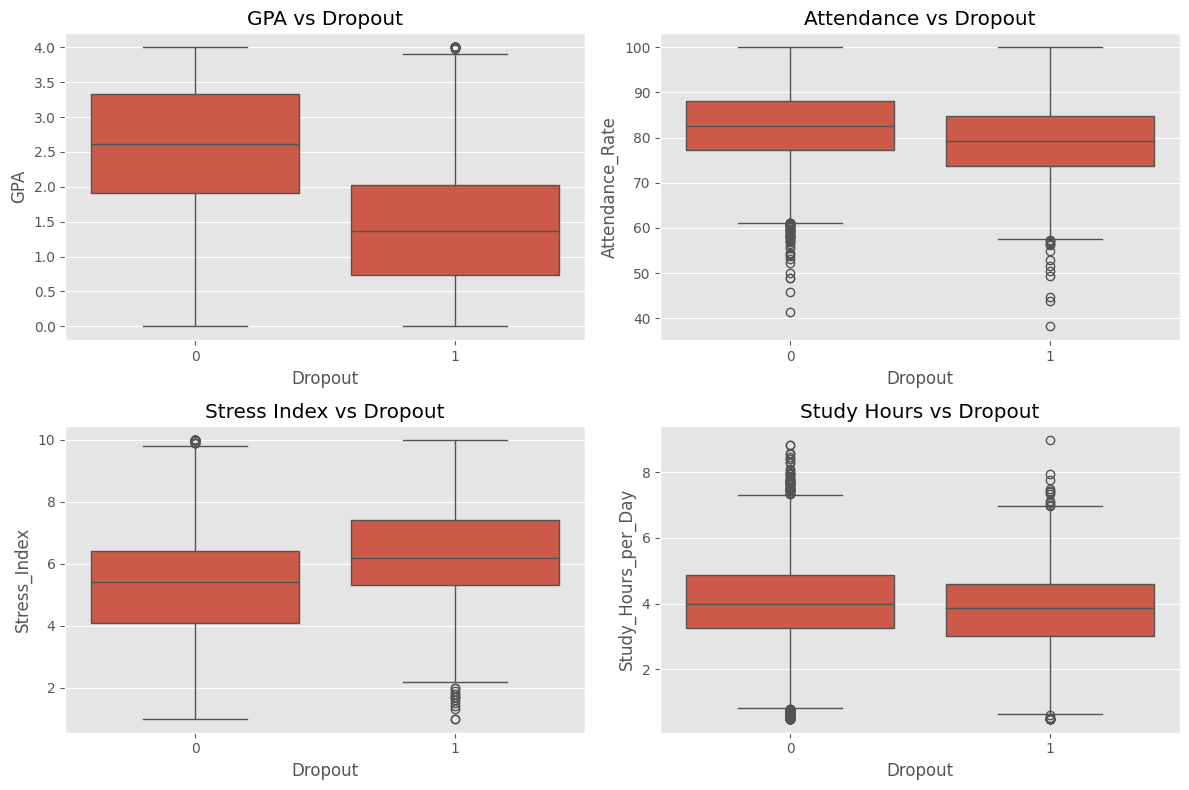

In [149]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x="Dropout", y="GPA", data=df, ax=axes[0,0])
axes[0,0].set_title("GPA vs Dropout")

sns.boxplot(x="Dropout", y="Attendance_Rate", data=df, ax=axes[0,1])
axes[0,1].set_title("Attendance vs Dropout")

sns.boxplot(x="Dropout", y="Stress_Index", data=df, ax=axes[1,0])
axes[1,0].set_title("Stress Index vs Dropout")

sns.boxplot(x="Dropout", y="Study_Hours_per_Day", data=df, ax=axes[1,1])
axes[1,1].set_title("Study Hours vs Dropout")

plt.tight_layout()
plt.show()

- GPA shows a strong separation between dropout and non-dropout students.
- Attendance and Stress Index show moderate differences with noticeable overlap.
- Study Hours shows minimal difference between the two groups.

GPA is the most important feature, while Attendance and Stress contribute moderately. Study Hours alone has weak predictive power.

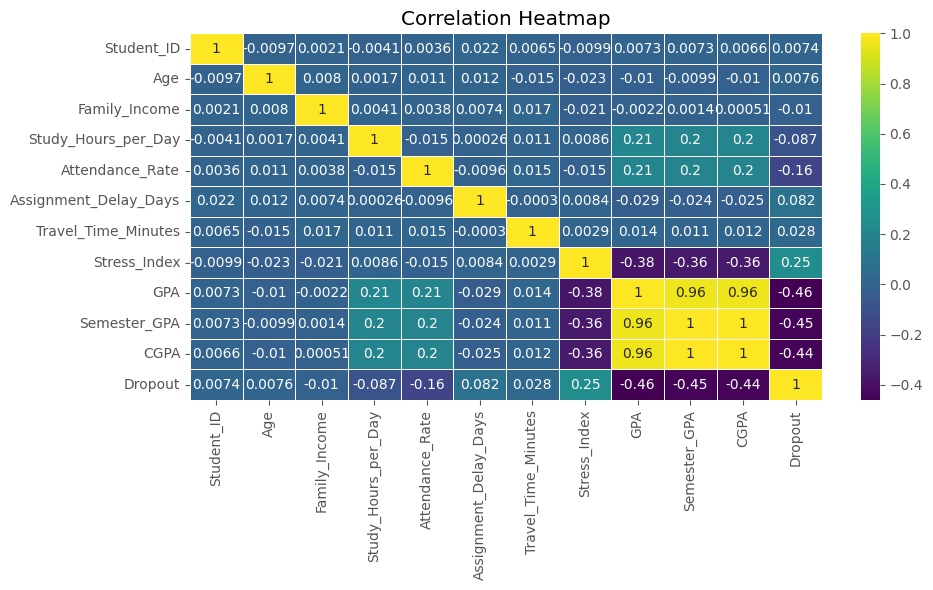

In [150]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

- High correlation was observed between GPA, Semester_GPA, and CGPA (correlation > 0.9). To avoid multicollinearity, only GPA was retained as it represents current academic performance, while Semester_GPA and CGPA were dropped.

In [151]:
df=df.drop(columns=["Semester_GPA","CGPA","Student_ID"])

In [152]:
df.columns

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester', 'Department', 'Parental_Education', 'Dropout'],
      dtype='object')


Correlation analysis revealed a very high correlation (> 0.9) between GPA, Semester_GPA, and CGPA, indicating multicollinearity. Since these features carry similar information, retaining all of them can negatively impact model stability and interpretability.
To address this, only GPA was retained as it reflects current academic performance, while Semester_GPA and CGPA were removed. Additionally, Student_ID was dropped as it does not contribute to prediction.
This step helps improve model reliability and prevents redundancy in features.


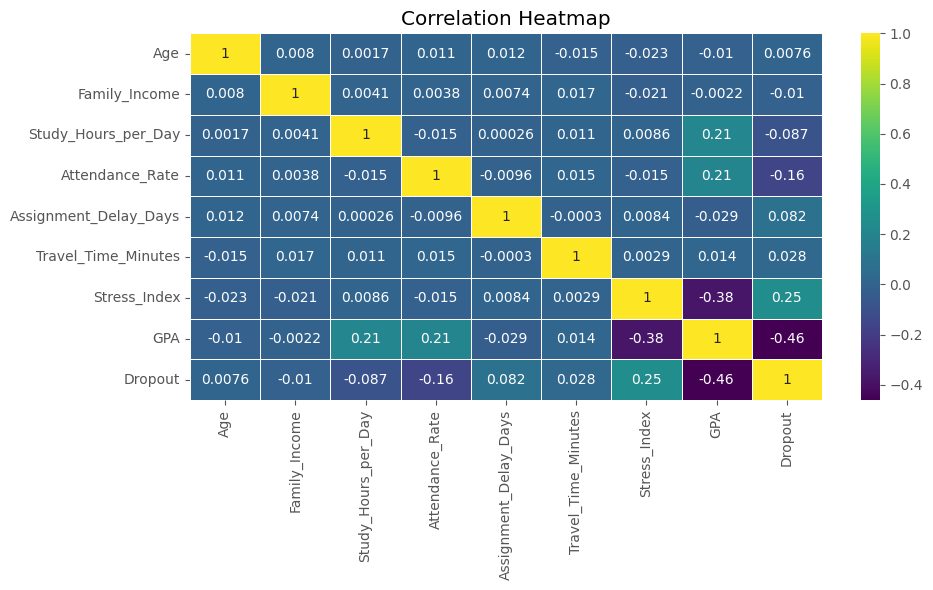

In [134]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()